In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
def f(t,y):
    return t*np.exp(t*3) - 2*y

def real_f(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)


def adams2(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1]= y0,real_f(ti + h)
    t[1] = t[0] + h
    for i in range(1,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/2)*(3*f(t[i],y[i]) - f(t[i - 1], y[i - 1]))

    return t,y

def adams3(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1],y[2]= y0,real_f(ti + h),real_f(ti + 2*h)
    t[1],t[2] = t[0] + h, t[0] + 2*h
    for i in range(2,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/12)*(23*f(t[i],y[i]) - 16*f(t[i - 1], y[i - 1]) + 5*f(t[i - 2],y[i - 2]))

    return t,y

def adams4(y0,h,ti,tf,f,real_f):
    N = int(np.ceil((tf-ti)/h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0],y[1],y[2],y[3]= y0,real_f(ti + h),real_f(ti + 2*h), real_f(ti + 3*h)
    t[1],t[2],t[3] = t[0] + h, t[0] + 2*h, t[0] + 3*h
    for i in range(3,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/24)*(55*f(t[i],y[i]) - 59*f(t[i - 1], y[i - 1]) + 37*f(t[i - 2],y[i - 2]) - 9*f(t[i - 3],y[i-3]))

    return t,y



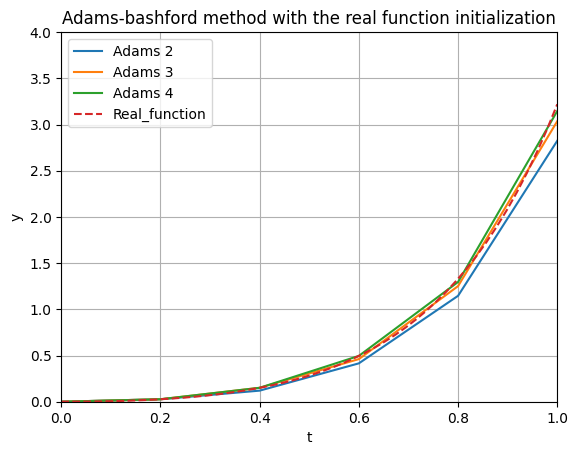

In [12]:
t_2,y_2 = adams2(0,0.2,0,1,f,real_f)
t_3,y_3 = adams3(0,0.2,0,1,f,real_f)
t_4,y_4 = adams4(0,0.2,0,1,f,real_f)
t_real = np.linspace(0,1)
plt.plot(t_2,y_2, label = "Adams 2")
plt.plot(t_3,y_3, label = "Adams 3")
plt.plot(t_4,y_4, label = "Adams 4")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.axis([0,1,0,4])
plt.title("Adams-bashford method with the real function initialization")
plt.savefig("Adams-bashford real init")
plt.legend()
plt.grid()
plt.show()

In [13]:
def runge_kutta_4(y0,h,ti,tf,f):
    N = int(np.ceil((tf - ti) / h))
    t = np.zeros(N + 1)
    y = np.zeros(N + 1)
    y[0] = y0
    t[0] = ti
    for i in range(N):
        k1 = h*f(t[i],y[i])
        k2 = h*f(t[i] + h/2, y[i] + (1/2)*k1)
        k3 = h*f(t[i] + h/2, y[i] + (1/2)*k2)
        t[i + 1] = t[i] + h
        k4 = h*f(t[i + 1],y[i] + k3)
        y[i + 1] = y[i] + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return t,y

In [14]:
def f(t,y):
    return -(y + 1)*(y + 3)

def real_f(t):
    return -3 + 2/(1 + np.exp(-2*t))

In [15]:
def adams2_RK(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t,r = runge_kutta_4(y0,h,ti,tf,f)
    y[0],y[1]= y0,r[1]
    for i in range(1,N):
        y[i + 1] = y[i] + (h/2)*(3*f(t[i],y[i]) - f(t[i - 1], y[i - 1]))

    return t,y

def adams3_RK(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t,r = runge_kutta_4(y0,h,ti,tf,f)
    y[0],y[1],y[2]= y0,r[1],r[2]
    for i in range(2,N):
        t[i + 1] = t[i] + h
        y[i + 1] = y[i] + (h/12)*(23*f(t[i],y[i]) - 16*f(t[i - 1], y[i - 1]) + 5*f(t[i - 2],y[i - 2]))

    return t,y

def adams4_RK(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t,r = runge_kutta_4(y0,h,ti,tf,f)
    y[0],y[1],y[2],y[3]= y0, r[1],r[2],r[3]
    for i in range(3,N):
        y[i + 1] = y[i] + (h/24)*(55*f(t[i],y[i]) - 59*f(t[i - 1], y[i - 1]) + 37*f(t[i - 2],y[i - 2]) - 9*f(t[i - 3],y[i-3]))
    
    return t,y


def adams2(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t = np.linspace(ti,tf,N + 1)
    r = real_f(t)
    t[0],t[1] = ti, ti + h
    y[0],y[1]= y0,r[1]
    for i in range(1,N):
        y[i + 1] = y[i] + (h/2)*(3*f(t[i],y[i]) - f(t[i - 1], y[i - 1]))

    return t,y

def adams3(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t = np.linspace(ti,tf,N + 1)
    r = real_f(t)
    y[0],y[1],y[2]= y0,r[1],r[2]
    for i in range(2,N):
        y[i + 1] = y[i] + (h/12)*(23*f(t[i],y[i]) - 16*f(t[i - 1], y[i - 1]) + 5*f(t[i - 2],y[i - 2]))

    return t,y

def adams4(y0,h,ti,tf,f):
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t = np.linspace(ti,tf,N + 1)
    r = real_f(t)
    y[0],y[1],y[2],y[3]= y0, r[1],r[2],r[3]
    for i in range(3,N):
        y[i + 1] = y[i] + (h/24)*(55*f(t[i],y[i]) - 59*f(t[i - 1], y[i - 1]) + 37*f(t[i - 2],y[i - 2]) - 9*f(t[i - 3],y[i-3]))

    return t,y




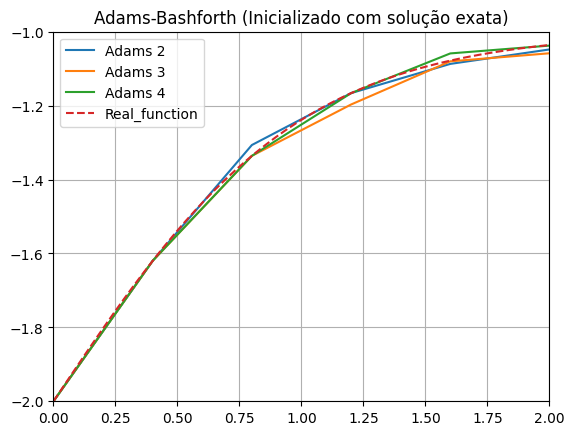

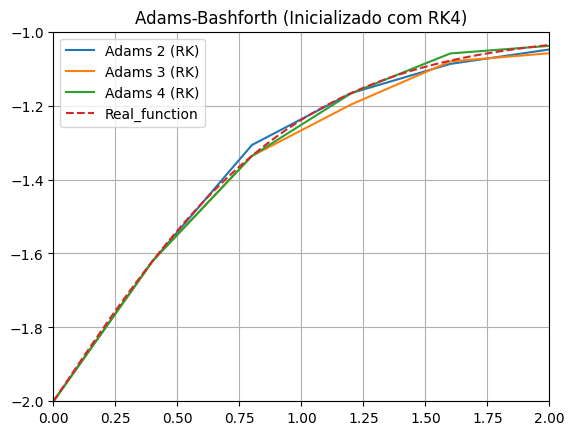

In [18]:
t_4,y_4 = adams4(-2,0.4,0,2,f)
t_3,y_3 = adams3(-2,0.4,0,2,f)
t_2,y_2 = adams2(-2,0.4,0,2,f)

t_2_rk,y_2_rk = adams2_RK(-2,0.4,0,2,f)
t_3_rk,y_3_rk = adams3_RK(-2,0.4,0,2,f)
t_4_rk,y_4_rk = adams4_RK(-2,0.4,0,2,f)

t_real = np.linspace(0,2)
plt.plot(t_2,y_2, label = "Adams 2")
plt.plot(t_3,y_3, label = "Adams 3")
plt.plot(t_4,y_4, label = "Adams 4")
plt.title("Adams-Bashforth (Inicializado com solução exata)")
plt.savefig("Adams-bashforth with real func init")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.legend()
plt.axis([0,2,-2,-1])
plt.grid()
plt.show()

plt.plot(t_2_rk,y_2_rk, label = "Adams 2 (RK)")
plt.plot(t_3_rk,y_3_rk, label = "Adams 3 (RK)")
plt.plot(t_4_rk,y_4_rk, label = "Adams 4 (RK)")
plt.title("Adams-Bashforth (Inicializado com RK4)")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.savefig("Adams-bashforth with RK")
plt.axis([0,2,-2,-1])
plt.legend()
plt.grid()
plt.show()